In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import pearsonr, kendalltau

In [2]:
from dl_permutations.genetic_alg.tsp import TSP

In [3]:
N = 10
DATASET_SIZE = 20_000
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-5
EMB_DIM = 32
HIDDEN_SIZE = 128
OUT_DIM = 64


rand_tsp_params = {'cities_count': N, 'min': 0, 'max': 10, 'start': 1, 'seed': 21}
new_map_params = {'cities_count': N, 'min': 0, 'max': 10, 'start': 1, 'seed': 99}


In [4]:
def get_leader(p):
    n = len(p)
    best_p = p.copy()
    for i in range(n):
        rot = np.roll(p, -i)
        if list(rot) < list(best_p): best_p = rot
        rot_rev = np.roll(p[::-1], -i)
        if list(rot_rev) < list(best_p): best_p = rot_rev
    return best_p


def tour_length(perm, coords):
    route = coords[perm]
    nxt = np.roll(route, shift=-1, axis=0)
    diffs = nxt - route
    return np.sqrt((diffs ** 2).sum(axis=1)).sum()


def kendall_distance(p1, p2):
    corr, _ = kendalltau(p1, p2)
    return (1.0 - corr) / 2.0


def build_unique_pool(tsp, pool_size):
    raw = tsp.generate_solutions(pool_size)
    canon = [tuple(get_leader(p)) for p in raw]
    unique = sorted(set(canon))
    return np.array(unique, dtype=np.int64)


def sample_pairs(pool, n_pairs, rng):
    idx_a = rng.integers(0, len(pool), size=n_pairs)
    idx_b = rng.integers(0, len(pool), size=n_pairs)
    return pool[idx_a], pool[idx_b]


def make_dataset(pool, coords, n_pairs, rng, norm_scale=None):
    perms_a, perms_b = sample_pairs(pool, n_pairs, rng)
    lengths_a = np.array([tour_length(p, coords) for p in perms_a], dtype=np.float32)
    lengths_b = np.array([tour_length(p, coords) for p in perms_b], dtype=np.float32)
    signed_diff = lengths_a - lengths_b
    if norm_scale is None:
        norm_scale = np.abs(signed_diff).max()
    targets = (signed_diff / norm_scale).astype(np.float32)
    kt = np.array([kendall_distance(a, b) for a, b in zip(perms_a, perms_b)], dtype=np.float32)
    return perms_a, perms_b, targets, kt, lengths_a, lengths_b, norm_scale

In [5]:
rng = np.random.default_rng(42)

tsp = TSP(**rand_tsp_params)
cities_coords = tsp.cities

full_pool = build_unique_pool(tsp, pool_size=DATASET_SIZE * 3)
rng.shuffle(full_pool)

n_total = len(full_pool)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

train_pool = full_pool[:n_train]
val_pool = full_pool[n_train:n_train + n_val]
test_pool = full_pool[n_train + n_val:]

n_train_pairs = int(DATASET_SIZE * TRAIN_RATIO)
n_val_pairs = int(DATASET_SIZE * VAL_RATIO)
n_test_pairs = int(DATASET_SIZE * TEST_RATIO)

x_a_train, x_b_train, y_train_np, kt_train, len_a_train, len_b_train, norm_scale = make_dataset(
    train_pool, cities_coords, n_train_pairs, rng
)
x_a_val, x_b_val, y_val_np, kt_val, len_a_val, len_b_val, _ = make_dataset(
    val_pool, cities_coords, n_val_pairs, rng, norm_scale=norm_scale
)
x_a_test, x_b_test, y_test_np, kt_test, len_a_test, len_b_test, _ = make_dataset(
    test_pool, cities_coords, n_test_pairs, rng, norm_scale=norm_scale
)

route_coords_a_test = cities_coords[x_a_test]
route_coords_b_test = cities_coords[x_b_test]

corr_kt_geo, _ = pearsonr(kt_train, np.abs(y_train_np))
print(f"Korelacja Kendall-Tau vs znorm. |roznica| dlugosci (train): {corr_kt_geo:.4f}")

def to_loader(xa, xb, y, kt, shuffle):
    ds = TensorDataset(
        torch.tensor(xa, dtype=torch.long),
        torch.tensor(xb, dtype=torch.long),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(kt, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


train_loader = to_loader(x_a_train, x_b_train, y_train_np, kt_train, True)
val_loader = to_loader(x_a_val, x_b_val, y_val_np, kt_val, False)
test_loader = to_loader(x_a_test, x_b_test, y_test_np, kt_test, False)

Korelacja Kendall-Tau vs znorm. |roznica| dlugosci (train): 0.0031


In [6]:
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size=N, emb_dim=EMB_DIM, hidden_size=HIDDEN_SIZE, out_dim=OUT_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_size, num_layers=1, batch_first=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, out_dim)
        )

    def forward(self, x):
        emb = self.embedding(x)
        _, (hn, _) = self.lstm(emb)
        return self.proj(hn.squeeze(0))


class SiameseNet(nn.Module):
    def __init__(self, encoder, use_kendall=False):
        super().__init__()
        self.encoder = encoder
        self.use_kendall = use_kendall
        self.score_head = nn.Linear(OUT_DIM, 1)
        if use_kendall:
            self.head = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x_a, x_b, kt=None):
        z_a = self.encoder(x_a)
        z_b = self.encoder(x_b)
        score_a = self.score_head(z_a).squeeze(1)
        score_b = self.score_head(z_b).squeeze(1)
        signed_diff = score_a - score_b
        if not self.use_kendall:
            return signed_diff
        feats = torch.stack([signed_diff, kt], dim=1)
        return self.head(feats).squeeze(1)


=== BEZ KENDALL-TAU ===


>>Epoch 0 | Train loss: 0.02141 | Val loss: 0.00107 | Patience: 0


>>Epoch 1 | Train loss: 0.00097 | Val loss: 0.00028 | Patience: 0


>>Epoch 2 | Train loss: 0.00050 | Val loss: 0.00023 | Patience: 0


>>Epoch 3 | Train loss: 0.00038 | Val loss: 0.00015 | Patience: 0


...

>>Epoch 25 | Train loss: 0.00023 | Val loss: 0.00007 | Patience: 2


>>Epoch 26 | Train loss: 0.00023 | Val loss: 0.00004 | Patience: 0


>>Epoch 27 | Train loss: 0.00023 | Val loss: 0.00006 | Patience: 1


>>Epoch 28 | Train loss: 0.00023 | Val loss: 0.00007 | Patience: 2


>>Epoch 29 | Train loss: 0.00027 | Val loss: 0.00006 | Patience: 3

--- POROWNANIE (test, ta sama mapa) ---
bez Kendall-Tau : MSE 0.00004 | Pearson 0.9997
z  Kendall-Tau  : MSE 0.00004 | Pearson 0.9997
Liczba permutacji wspolnych dla train i test: 0


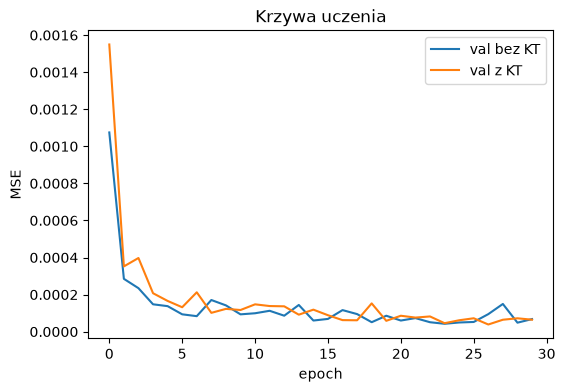

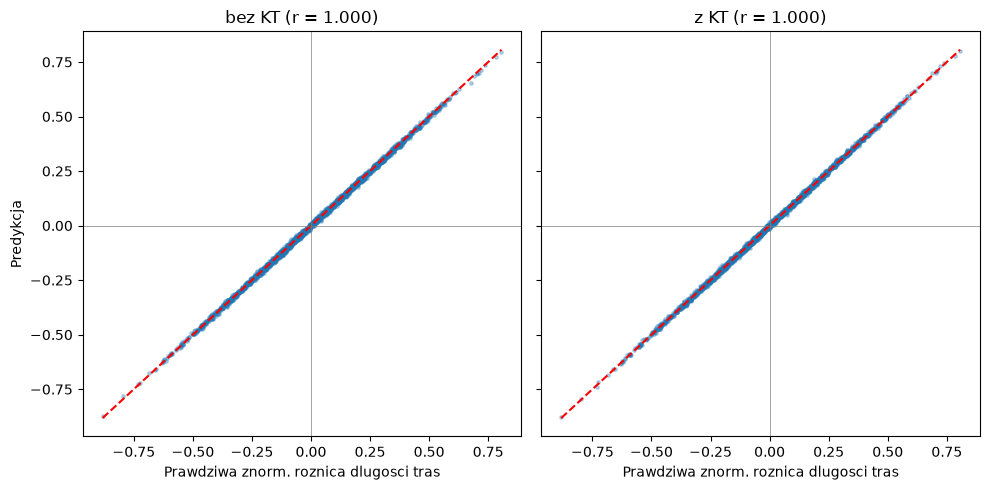


--- NAJGORSZE PRZYPADKI (ta sama mapa) ---


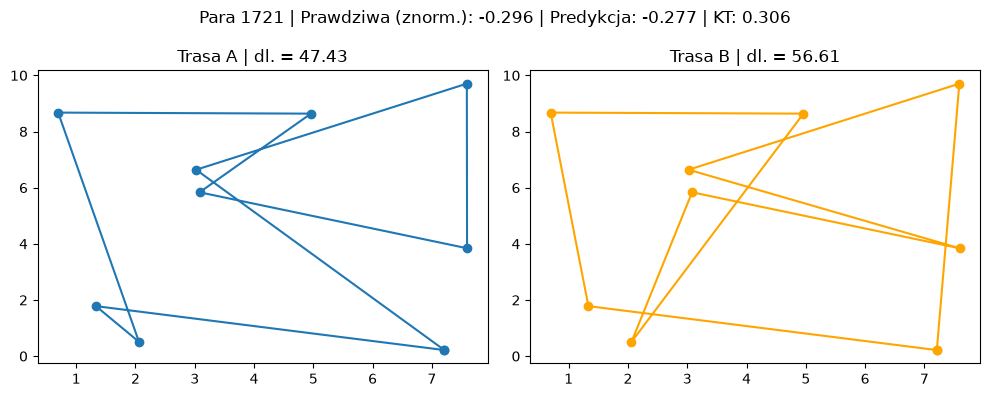

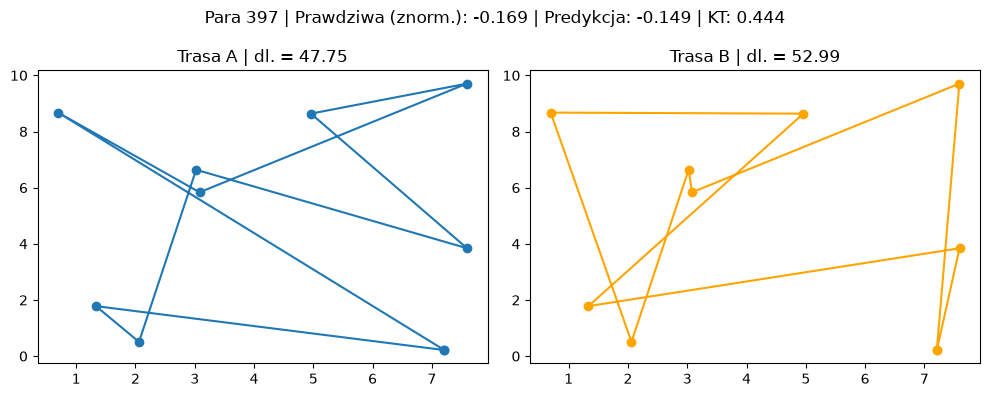

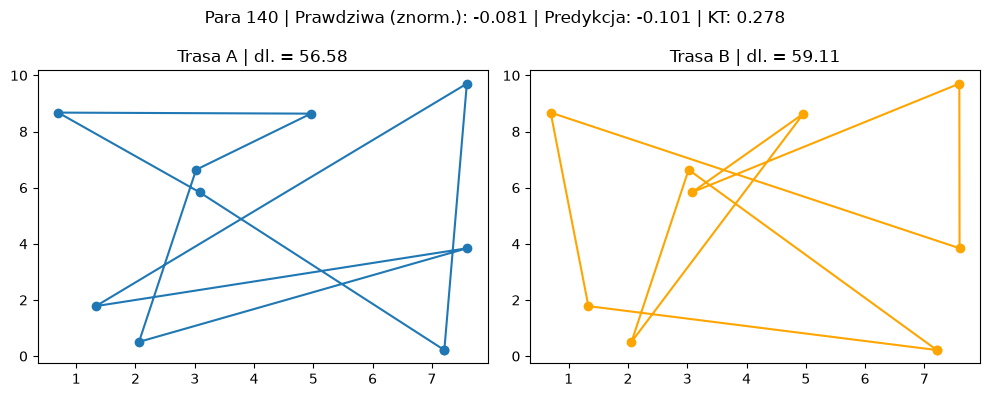

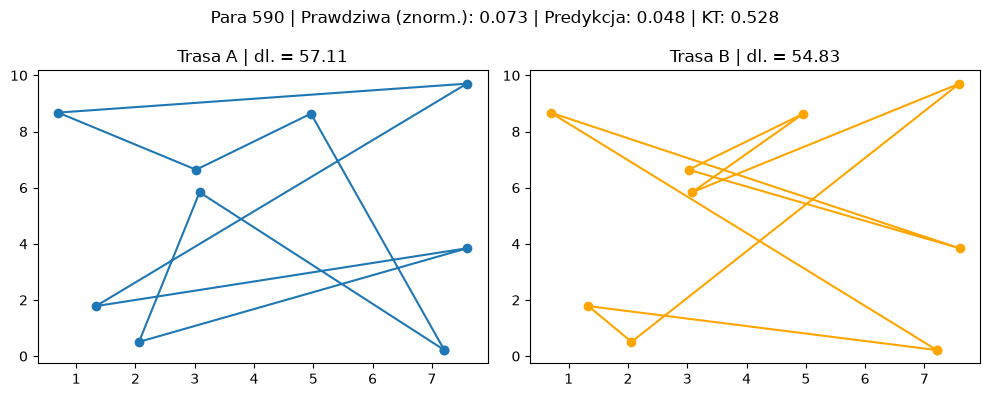

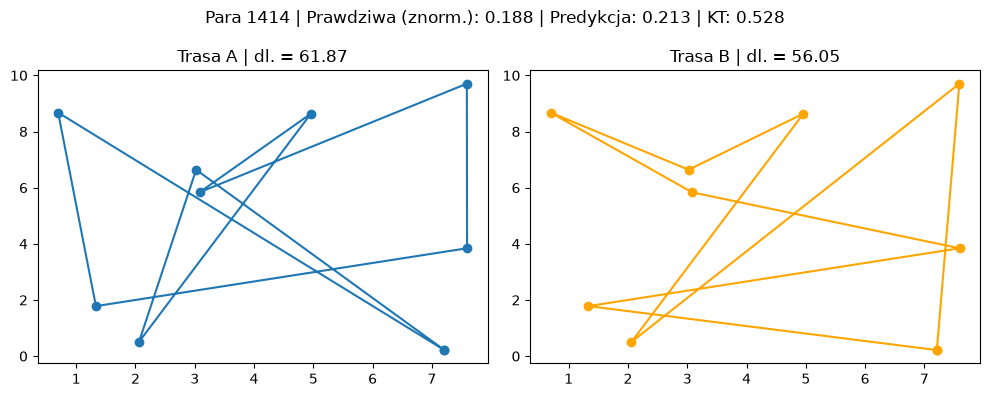


--- NAJLEPSZE PRZYPADKI (ta sama mapa) ---


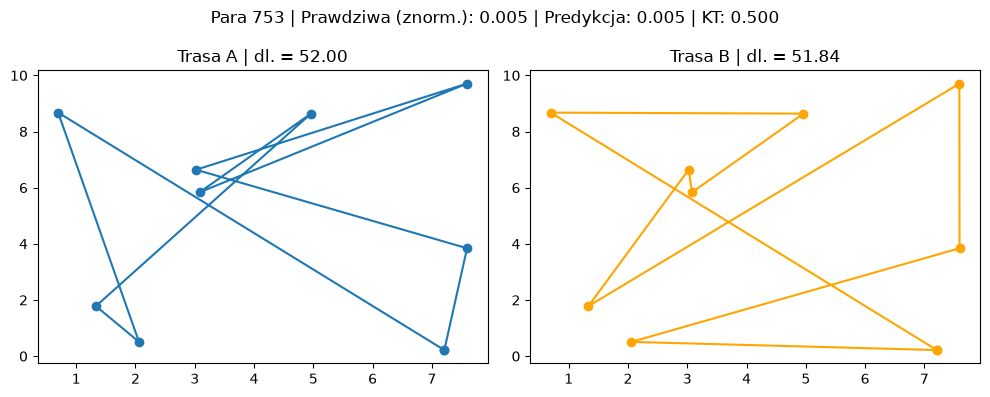

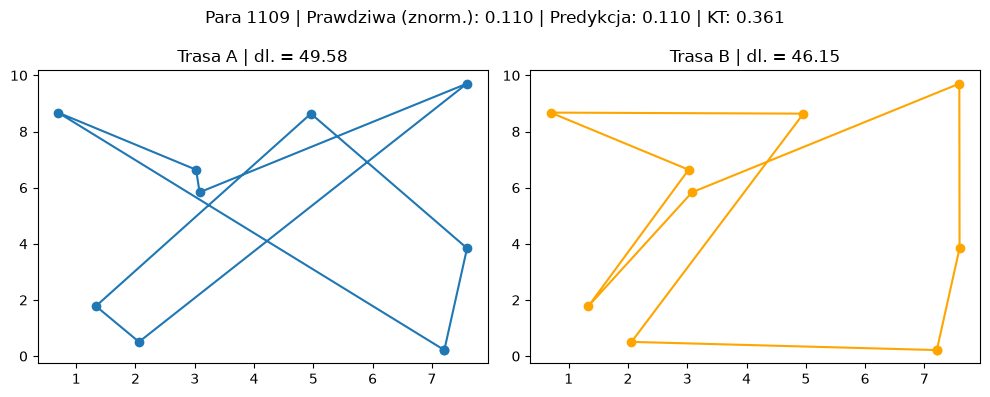

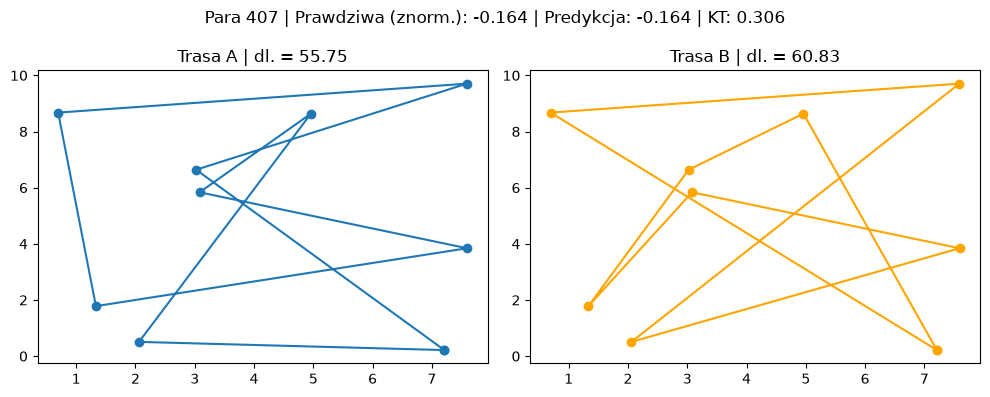

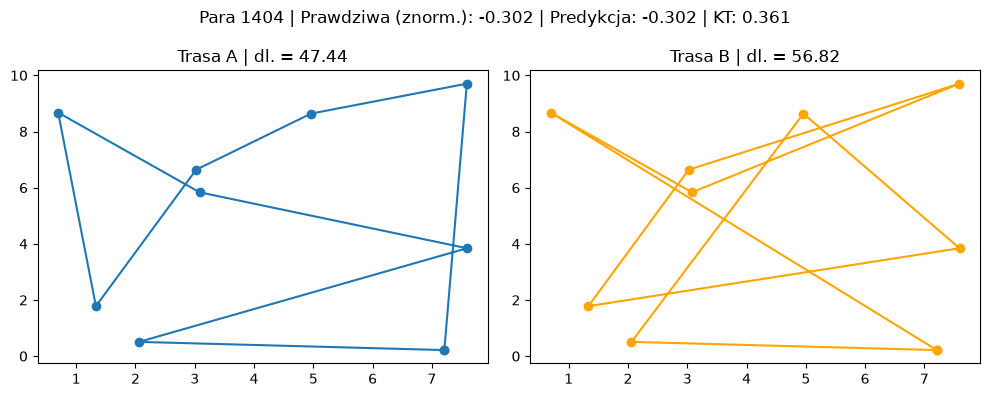

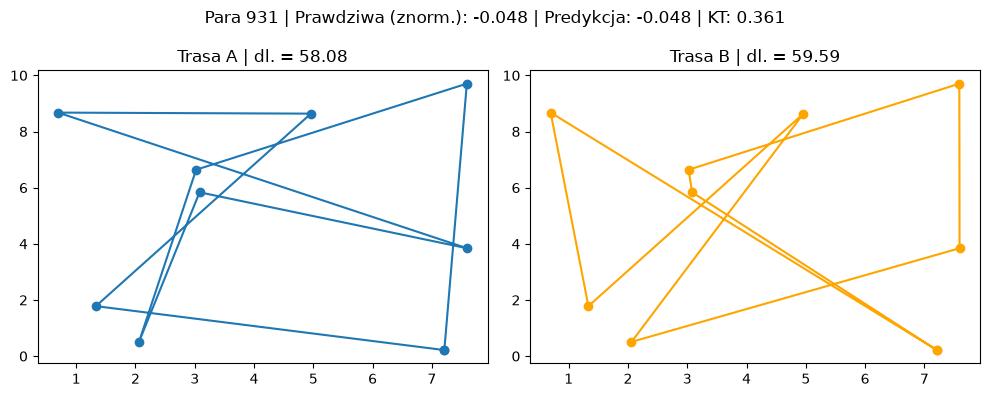


--- TEST GENERALIZACJI NA NOWEJ MAPIE (seed=99) ---
bez Kendall-Tau : Pearson -0.1982
z  Kendall-Tau  : Pearson -0.1966


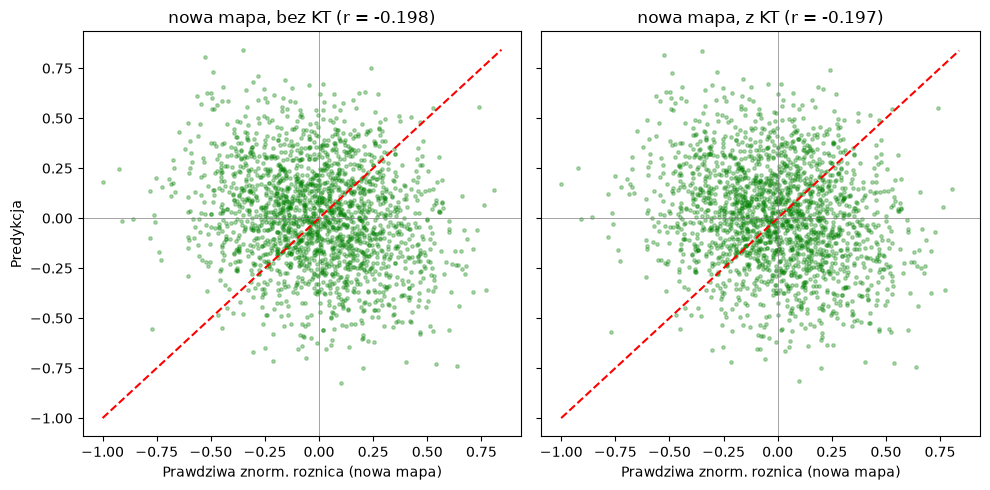

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.MSELoss()
MAX_PATIENCE = 10


def train_and_eval(use_kendall, save_path):
    torch.manual_seed(0)
    model = SiameseNet(RNNEncoder(), use_kendall=use_kendall).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    loss_history, val_loss_history = [], []
    best_loss = np.inf
    patience = 0

    for epoch in range(EPOCHS):
        model.train()
        avg_loss = 0
        for xa, xb, tg, kt in train_loader:
            xa, xb, tg, kt = xa.to(device), xb.to(device), tg.to(device), kt.to(device)
            outputs = model(xa, xb, kt)
            loss = criterion(outputs, tg)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            avg_loss += loss.item()
        loss_history.append(avg_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xa, xb, tg, kt in val_loader:
                xa, xb, tg, kt = xa.to(device), xb.to(device), tg.to(device), kt.to(device)
                val_loss += criterion(model(xa, xb, kt), tg).item()
        val_loss /= len(val_loader)
        val_loss_history.append(val_loss)

        if val_loss < best_loss:
            patience = 0
            best_loss = val_loss
            torch.save(model.state_dict(), save_path)
        else:
            patience += 1

        if patience == MAX_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}")
            break

        print(f">>Epoch {epoch} | Train loss: {loss_history[-1]:.5f} | Val loss: {val_loss:.5f} | Patience: {patience}")

    best_model = SiameseNet(RNNEncoder(), use_kendall=use_kendall).to(device)
    best_model.load_state_dict(torch.load(save_path, weights_only=True))
    best_model.eval()

    avg_test_loss = 0
    test_outputs = []
    with torch.no_grad():
        for xa, xb, tg, kt in test_loader:
            xa, xb, tg, kt = xa.to(device), xb.to(device), tg.to(device), kt.to(device)
            outputs = best_model(xa, xb, kt)
            avg_test_loss += criterion(outputs, tg).item()
            test_outputs.append(outputs.cpu().numpy())

    test_outputs = np.concatenate(test_outputs)
    avg_test_loss /= len(test_loader)
    corr, _ = pearsonr(y_test_np, test_outputs)
    return best_model, test_outputs, avg_test_loss, corr, loss_history, val_loss_history


print("\n=== BEZ KENDALL-TAU ===")
model_base, out_base, loss_base, corr_base, hist_base, vhist_base = train_and_eval(
    False, 'siamese_geo_base.pt'
)

print("\n=== Z KENDALL-TAU ===")
model_kt, out_kt, loss_kt, corr_kt, hist_kt, vhist_kt = train_and_eval(
    True, 'siamese_geo_kt.pt'
)

print("\n--- POROWNANIE (test, ta sama mapa) ---")
print(f"bez Kendall-Tau : MSE {loss_base:.5f} | Pearson {corr_base:.4f}")
print(f"z  Kendall-Tau  : MSE {loss_kt:.5f} | Pearson {corr_kt:.4f}")

overlap_train_test = set(map(tuple, x_a_train)) & set(map(tuple, x_a_test))
overlap_train_test |= set(map(tuple, x_b_train)) & set(map(tuple, x_b_test))
print(f"Liczba permutacji wspolnych dla train i test: {len(overlap_train_test)}")

plt.figure(figsize=(6, 4))
plt.plot(vhist_base, label="val bez KT")
plt.plot(vhist_kt, label="val z KT")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Krzywa uczenia")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for a, (out, ttl, c) in zip(ax, [(out_base, "bez KT", corr_base), (out_kt, "z KT", corr_kt)]):
    a.scatter(y_test_np, out, s=6, alpha=0.3)
    lo = min(y_test_np.min(), out.min())
    hi = max(y_test_np.max(), out.max())
    lims = [lo, hi]
    a.plot(lims, lims, 'r--')
    a.axhline(0, color='gray', linewidth=0.5)
    a.axvline(0, color='gray', linewidth=0.5)
    a.set_xlabel("Prawdziwa znorm. roznica dlugosci tras")
    a.set_title(f"{ttl} (r = {c:.3f})")
ax[0].set_ylabel("Predykcja")
plt.tight_layout()
plt.show()

test_outputs = out_kt
errors = np.abs(y_test_np - test_outputs)
worst_cases = np.argsort(errors)[-5:]
best_cases = np.argsort(errors)[:5]


def draw_solution_pair(idx):
    c_a = route_coords_a_test[idx]
    c_b = route_coords_b_test[idx]
    c_a_closed = np.vstack([c_a, c_a[:1]])
    c_b_closed = np.vstack([c_b, c_b[:1]])

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(c_a_closed[:, 0], c_a_closed[:, 1], marker='o')
    ax[0].set_title(f"Trasa A | dl. = {len_a_test[idx]:.2f}")
    ax[1].plot(c_b_closed[:, 0], c_b_closed[:, 1], marker='o', color='orange')
    ax[1].set_title(f"Trasa B | dl. = {len_b_test[idx]:.2f}")
    plt.suptitle(
        f"Para {idx} | Prawdziwa (znorm.): {y_test_np[idx]:.3f} | "
        f"Predykcja: {test_outputs[idx]:.3f} | KT: {kt_test[idx]:.3f}"
    )
    plt.tight_layout()
    plt.show()


print("\n--- NAJGORSZE PRZYPADKI (ta sama mapa) ---")
for c in worst_cases:
    draw_solution_pair(c)

print("\n--- NAJLEPSZE PRZYPADKI (ta sama mapa) ---")
for c in best_cases:
    draw_solution_pair(c)

new_tsp = TSP(**new_map_params)
new_coords = new_tsp.cities
new_pool = build_unique_pool(new_tsp, pool_size=DATASET_SIZE)
new_rng = np.random.default_rng(7)

x_a_new, x_b_new, y_new_np, kt_new, len_a_new, len_b_new, new_norm_scale = make_dataset(
    new_pool, new_coords, n_test_pairs, new_rng
)

x_a_new_t = torch.tensor(x_a_new, dtype=torch.long).to(device)
x_b_new_t = torch.tensor(x_b_new, dtype=torch.long).to(device)
kt_new_t = torch.tensor(kt_new, dtype=torch.float32).to(device)

with torch.no_grad():
    new_out_base = model_base(x_a_new_t, x_b_new_t, kt_new_t).cpu().numpy()
    new_out_kt = model_kt(x_a_new_t, x_b_new_t, kt_new_t).cpu().numpy()

corr_new_base, _ = pearsonr(y_new_np, new_out_base)
corr_new_kt, _ = pearsonr(y_new_np, new_out_kt)

print(f"\n--- TEST GENERALIZACJI NA NOWEJ MAPIE (seed={new_map_params['seed']}) ---")
print(f"bez Kendall-Tau : Pearson {corr_new_base:.4f}")
print(f"z  Kendall-Tau  : Pearson {corr_new_kt:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for a, (out, ttl, c) in zip(ax, [(new_out_base, "bez KT", corr_new_base),
                                 (new_out_kt, "z KT", corr_new_kt)]):
    a.scatter(y_new_np, out, s=6, alpha=0.3, color='green')
    lo_new = min(y_new_np.min(), out.min())
    hi_new = max(y_new_np.max(), out.max())
    lims_new = [lo_new, hi_new]
    a.plot(lims_new, lims_new, 'r--')
    a.axhline(0, color='gray', linewidth=0.5)
    a.axvline(0, color='gray', linewidth=0.5)
    a.set_xlabel("Prawdziwa znorm. roznica (nowa mapa)")
    a.set_title(f"nowa mapa, {ttl} (r = {c:.3f})")
ax[0].set_ylabel("Predykcja")
plt.tight_layout()
plt.show()